# ML4SCI – HEPSIM GSoC 2026 Test


In [1]:
import os
import math
import random
import urllib.request
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

try:
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix
    SKLEARN_AVAILABLE = True
except Exception:
    SKLEARN_AVAILABLE = False

plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(precision=5, suppress=True)

SEED = 42
rng = np.random.default_rng(SEED)
random.seed(SEED)

ON_KAGGLE = Path("/kaggle/input").exists()
WORK_DIR = Path("/kaggle/working") if ON_KAGGLE else Path(".")
DATA_DIR = WORK_DIR / "data_qg_jets"
DATA_DIR.mkdir(parents=True, exist_ok=True)

MAX_FILES = 5
MAX_JETS_TOTAL = 500_000
BATCH_SIZE = 5000

ZENODO_RECORD = "https://zenodo.org/records/3164691"
BASE_FILE_URL = "https://zenodo.org/records/3164691/files"

STANDARD_FILES = [
    "QG_jets.npz",
    "QG_jets_1.npz",
    "QG_jets_2.npz",
    "QG_jets_3.npz",
    "QG_jets_4.npz",
    "QG_jets_5.npz",
    "QG_jets_6.npz",
    "QG_jets_7.npz",
    "QG_jets_8.npz",
    "QG_jets_9.npz",
    "QG_jets_10.npz",
    "QG_jets_11.npz",
    "QG_jets_12.npz",
    "QG_jets_13.npz",
    "QG_jets_14.npz",
    "QG_jets_15.npz",
    "QG_jets_16.npz",
    "QG_jets_17.npz",
    "QG_jets_18.npz",
    "QG_jets_19.npz",
]
SELECTED_FILES = STANDARD_FILES[:MAX_FILES]

print(f"Running on Kaggle: {ON_KAGGLE}")
print(f"Using {len(SELECTED_FILES)} file(s):")
for f in SELECTED_FILES:
    print("  -", f)


Running on Kaggle: True
Using 5 file(s):
  - QG_jets.npz
  - QG_jets_1.npz
  - QG_jets_2.npz
  - QG_jets_3.npz
  - QG_jets_4.npz


In [2]:
def discover_kaggle_input_files(root=Path("/kaggle/input")):
    found = {}
    if not root.exists():
        return found
    for path in root.rglob("QG_jets*.npz"):
        name = path.name
        if "withbc" in name:
            continue
        if name in STANDARD_FILES and name not in found:
            found[name] = path
    return found

def download_selected_files(selected_files, data_dir=DATA_DIR):
    paths = []
    for name in selected_files:
        path = data_dir / name
        if not path.exists():
            url = f"{BASE_FILE_URL}/{name}?download=1"
            print(f"Downloading {name} ...")
            urllib.request.urlretrieve(url, path)
        else:
            print(f"Found existing local file: {name}")
        paths.append(path)
    return paths

def resolve_file_paths(selected_files):
    discovered = discover_kaggle_input_files()
    if discovered:
        missing = [name for name in selected_files if name not in discovered]
        if not missing:
            print("Using dataset files discovered under /kaggle/input")
            return [discovered[name] for name in selected_files]
        print("Found some standard files under /kaggle/input, but not all requested.")
        print("Missing:", missing)
        print("Falling back to local/downloaded copies for the full requested set.")
    else:
        print("No attached QG dataset found under /kaggle/input.")
    return download_selected_files(selected_files)

file_paths = resolve_file_paths(SELECTED_FILES)
print("\nAll files ready:")
for p in file_paths:
    print("  -", p)


Using dataset files discovered under /kaggle/input

All files ready:
  - /kaggle/input/datasets/srijanroysr10/quark-gluon-datasets/QG_jets.npz
  - /kaggle/input/datasets/srijanroysr10/quark-gluon-datasets/QG_jets_1.npz
  - /kaggle/input/datasets/srijanroysr10/quark-gluon-datasets/QG_jets_2.npz
  - /kaggle/input/datasets/srijanroysr10/quark-gluon-datasets/QG_jets_3.npz
  - /kaggle/input/datasets/srijanroysr10/quark-gluon-datasets/QG_jets_4.npz


In [3]:
sample = np.load(file_paths[0], allow_pickle=False)
print("Keys:", list(sample.keys()))
print("X shape:", sample["X"].shape)
print("y shape:", sample["y"].shape)
sample.close()

Keys: ['X', 'y']
X shape: (100000, 139, 4)
y shape: (100000,)


## Helper functions



In [4]:
def delta_phi(phi1, phi2):
    d = phi1 - phi2
    return np.arctan2(np.sin(d), np.cos(d))

def features_to_fourmomenta(pt, eta, phi):
    px = pt * np.cos(phi)
    py = pt * np.sin(phi)
    pz = pt * np.sinh(eta)
    E = pt * np.cosh(eta)
    return E, px, py, pz

def summarize_batch(Xb, yb):
    pt = Xb[:, :, 0]
    eta = Xb[:, :, 1]
    phi = Xb[:, :, 2]

    mask = pt > 0
    mult = mask.sum(axis=1)
    sum_pt = pt.sum(axis=1)

    lead_idx = np.argmax(pt, axis=1)
    row = np.arange(len(Xb))
    lead_pt = pt[row, lead_idx]
    lead_eta = eta[row, lead_idx]

    E, px, py, pz = features_to_fourmomenta(pt, eta, phi)
    jet_E = E.sum(axis=1)
    jet_px = px.sum(axis=1)
    jet_py = py.sum(axis=1)
    jet_pz = pz.sum(axis=1)

    jet_pt = np.hypot(jet_px, jet_py)
    jet_eta = np.arcsinh(jet_pz / np.clip(jet_pt, 1e-12, None))
    jet_phi = np.arctan2(jet_py, jet_px)

    m2 = jet_E**2 - jet_px**2 - jet_py**2 - jet_pz**2
    jet_mass = np.sqrt(np.clip(m2, 0.0, None))

    dphi = delta_phi(phi, jet_phi[:, None])
    dR = np.sqrt((eta - jet_eta[:, None])**2 + dphi**2) * mask
    jet_width = (pt * dR).sum(axis=1) / np.clip(sum_pt, 1e-12, None)
    ptd = np.sqrt((pt**2).sum(axis=1)) / np.clip(sum_pt, 1e-12, None)

    return {
        "labels": yb.astype(np.int64),
        "multiplicity": mult.astype(np.int32),
        "leading_pt": lead_pt.astype(np.float32),
        "leading_eta": lead_eta.astype(np.float32),
        "jet_mass": jet_mass.astype(np.float32),
        "jet_width": jet_width.astype(np.float32),
        "ptd": ptd.astype(np.float32),
        "jet_E": jet_E.astype(np.float32),
        "jet_px": jet_px.astype(np.float32),
        "jet_py": jet_py.astype(np.float32),
        "jet_pz": jet_pz.astype(np.float32),
    }

In [5]:
def lorentz_boost_to_rest(E, px, py, pz):
    """
    Vectorized Lorentz boost of a batch of jets to each jet's own rest frame.

    Inputs:
        E, px, py, pz : arrays of shape (N_jets, N_constituents)

    Returns:
        E', px', py', pz' in the frame where the total three-momentum of each jet vanishes.
    """
    jet_E = E.sum(axis=1)
    jet_px = px.sum(axis=1)
    jet_py = py.sum(axis=1)
    jet_pz = pz.sum(axis=1)

    beta = np.stack([jet_px, jet_py, jet_pz], axis=1) / np.clip(jet_E[:, None], 1e-12, None)
    beta2 = np.sum(beta**2, axis=1)
    beta2 = np.clip(beta2, 0.0, 1.0 - 1e-12)
    gamma = 1.0 / np.sqrt(1.0 - beta2)

    p = np.stack([px, py, pz], axis=2)
    bp = np.einsum("nij,nj->ni", p, beta)

    coeff = np.zeros_like(beta2)
    nz = beta2 > 1e-15
    coeff[nz] = (gamma[nz] - 1.0) / beta2[nz]

    factor = coeff[:, None] * bp - gamma[:, None] * E
    p_prime = p + factor[:, :, None] * beta[:, None, :]
    E_prime = gamma[:, None] * (E - bp)

    return E_prime, p_prime[:, :, 0], p_prime[:, :, 1], p_prime[:, :, 2]

def boost_jet_to_rest_frame(jet_features):
    """
    Single-jet helper.

    Input:
        jet_features shape = (n_constituents, 4)
        columns = (pt, eta_or_y, phi, pdgid)

    Output:
        array of shape (n_valid_constituents, 4)
        columns = (E', px', py', pz')
    """
    jet = np.asarray(jet_features)
    jet = jet[jet[:, 0] > 0]
    pt = jet[:, 0][None, :]
    eta = jet[:, 1][None, :]
    phi = jet[:, 2][None, :]
    E, px, py, pz = features_to_fourmomenta(pt, eta, phi)
    Ep, pxp, pyp, pzp = lorentz_boost_to_rest(E, px, py, pz)
    out = np.stack([Ep[0], pxp[0], pyp[0], pzp[0]], axis=1)
    return out

def rest_frame_shape_features(Ep, pxp, pyp, pzp, mask):
    p2 = pxp**2 + pyp**2 + pzp**2
    pmag = np.sqrt(np.clip(p2, 0.0, None))
    denom = np.clip(p2.sum(axis=1), 1e-12, None)

    S = np.zeros((len(Ep), 3, 3), dtype=np.float64)
    S[:, 0, 0] = (pxp * pxp).sum(axis=1) / denom
    S[:, 1, 1] = (pyp * pyp).sum(axis=1) / denom
    S[:, 2, 2] = (pzp * pzp).sum(axis=1) / denom
    S[:, 0, 1] = S[:, 1, 0] = (pxp * pyp).sum(axis=1) / denom
    S[:, 0, 2] = S[:, 2, 0] = (pxp * pzp).sum(axis=1) / denom
    S[:, 1, 2] = S[:, 2, 1] = (pyp * pzp).sum(axis=1) / denom

    evals, evecs = np.linalg.eigh(S)
    l1, l2, l3 = evals[:, 2], evals[:, 1], evals[:, 0]

    sphericity = 1.5 * (l2 + l3)
    aplanarity = 1.5 * l3

    principal_axis = evecs[:, :, 2]
    p = np.stack([pxp, pyp, pzp], axis=2)
    proj = np.abs(np.einsum("nij,nj->ni", p, principal_axis))
    thrust_like = proj.sum(axis=1) / np.clip(pmag.sum(axis=1), 1e-12, None)

    energy_sum = np.clip(Ep.sum(axis=1), 1e-12, None)
    max_energy_fraction = np.max(np.where(mask, Ep, -np.inf), axis=1) / energy_sum
    mean_abs_cos_theta = proj.sum(axis=1) / np.clip(pmag.sum(axis=1), 1e-12, None)

    return {
        "rest_sphericity": sphericity.astype(np.float32),
        "rest_aplanarity": aplanarity.astype(np.float32),
        "rest_thrust_like": thrust_like.astype(np.float32),
        "rest_max_energy_fraction": max_energy_fraction.astype(np.float32),
        "rest_mean_abs_cos_theta": mean_abs_cos_theta.astype(np.float32),
    }

In [6]:
labels_all = []
mult_all = []
leading_pt_all = []
leading_eta_all = []
mass_all = []
width_all = []
ptd_all = []

rest_sphericity_all = []
rest_aplanarity_all = []
rest_thrust_all = []
rest_maxef_all = []
rest_meanabs_all = []

n_const_quark = 0
n_const_gluon = 0
n_jets_seen = 0

for path in file_paths:
    data = np.load(path, allow_pickle=False)
    X = data["X"]
    y = data["y"]

    start = 0
    while start < len(X) and n_jets_seen < MAX_JETS_TOTAL:
        stop = min(start + BATCH_SIZE, len(X), start + (MAX_JETS_TOTAL - n_jets_seen))
        Xb = X[start:stop]
        yb = y[start:stop]

        batch = summarize_batch(Xb, yb)

        labels_all.append(batch["labels"])
        mult_all.append(batch["multiplicity"])
        leading_pt_all.append(batch["leading_pt"])
        leading_eta_all.append(batch["leading_eta"])
        mass_all.append(batch["jet_mass"])
        width_all.append(batch["jet_width"])
        ptd_all.append(batch["ptd"])

        n_const_gluon += int(batch["multiplicity"][batch["labels"] == 0].sum())
        n_const_quark += int(batch["multiplicity"][batch["labels"] == 1].sum())

        pt = Xb[:, :, 0]
        eta = Xb[:, :, 1]
        phi = Xb[:, :, 2]
        mask = pt > 0

        E, px, py, pz = features_to_fourmomenta(pt, eta, phi)
        Ep, pxp, pyp, pzp = lorentz_boost_to_rest(E, px, py, pz)
        rfeat = rest_frame_shape_features(Ep, pxp, pyp, pzp, mask)

        rest_sphericity_all.append(rfeat["rest_sphericity"])
        rest_aplanarity_all.append(rfeat["rest_aplanarity"])
        rest_thrust_all.append(rfeat["rest_thrust_like"])
        rest_maxef_all.append(rfeat["rest_max_energy_fraction"])
        rest_meanabs_all.append(rfeat["rest_mean_abs_cos_theta"])

        n_jets_seen += len(Xb)
        start = stop

    data.close()
    if n_jets_seen >= MAX_JETS_TOTAL:
        break

labels = np.concatenate(labels_all)
multiplicity = np.concatenate(mult_all)
leading_pt = np.concatenate(leading_pt_all)
leading_eta = np.concatenate(leading_eta_all)
jet_mass = np.concatenate(mass_all)
jet_width = np.concatenate(width_all)
ptd = np.concatenate(ptd_all)

rest_sphericity = np.concatenate(rest_sphericity_all)
rest_aplanarity = np.concatenate(rest_aplanarity_all)
rest_thrust_like = np.concatenate(rest_thrust_all)
rest_max_energy_fraction = np.concatenate(rest_maxef_all)
rest_mean_abs_cos_theta = np.concatenate(rest_meanabs_all)

print(f"Processed jets: {len(labels):,}")
print(f"  gluon jets : {(labels == 0).sum():,}")
print(f"  quark jets : {(labels == 1).sum():,}")
print()
print("Total number of constituents (padding excluded):")
print(f"  gluon jets : {n_const_gluon:,}")
print(f"  quark jets : {n_const_quark:,}")

Processed jets: 500,000
  gluon jets : 250,000
  quark jets : 250,000

Total number of constituents (padding excluded):
  gluon jets : 13,288,604
  quark jets : 8,347,536


Average constituent multiplicity:
  gluon jets : 53.154
  quark jets : 33.390


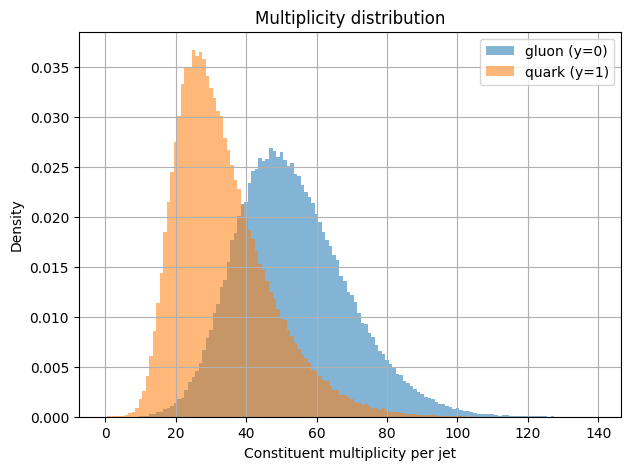

In [7]:
gmask = labels == 0
qmask = labels == 1

print("Average constituent multiplicity:")
print(f"  gluon jets : {multiplicity[gmask].mean():.3f}")
print(f"  quark jets : {multiplicity[qmask].mean():.3f}")

plt.figure(figsize=(7, 5))
bins = np.arange(0, multiplicity.max() + 2) - 0.5
plt.hist(multiplicity[gmask], bins=bins, alpha=0.55, density=True, label="gluon (y=0)")
plt.hist(multiplicity[qmask], bins=bins, alpha=0.55, density=True, label="quark (y=1)")
plt.xlabel("Constituent multiplicity per jet")
plt.ylabel("Density")
plt.title("Multiplicity distribution")
plt.legend()
plt.show()

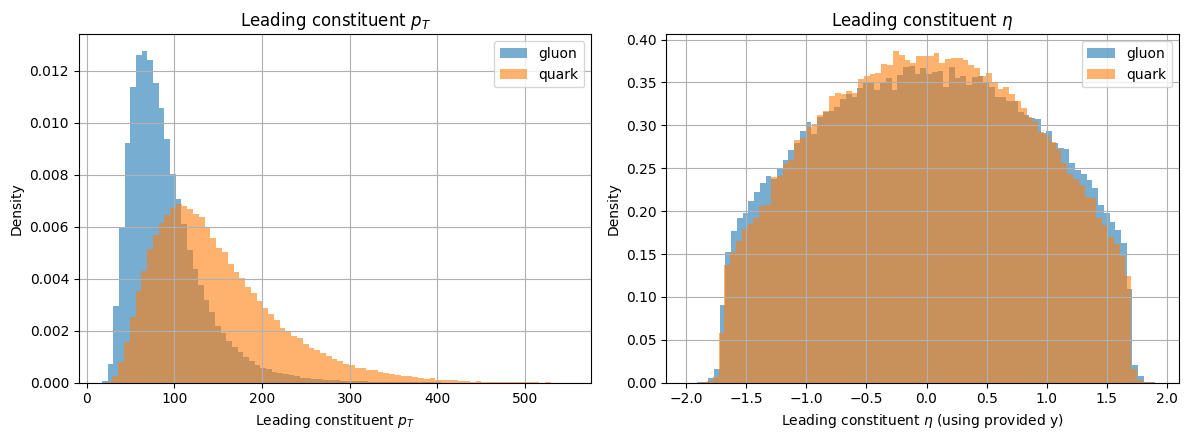

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

ax[0].hist(leading_pt[gmask], bins=80, alpha=0.6, density=True, label="gluon")
ax[0].hist(leading_pt[qmask], bins=80, alpha=0.6, density=True, label="quark")
ax[0].set_xlabel("Leading constituent $p_T$")
ax[0].set_ylabel("Density")
ax[0].set_title("Leading constituent $p_T$")
ax[0].legend()

ax[1].hist(leading_eta[gmask], bins=80, alpha=0.6, density=True, label="gluon")
ax[1].hist(leading_eta[qmask], bins=80, alpha=0.6, density=True, label="quark")
ax[1].set_xlabel("Leading constituent $\\eta$ (using provided y)")
ax[1].set_ylabel("Density")
ax[1].set_title("Leading constituent $\\eta$")
ax[1].legend()

plt.tight_layout()
plt.show()

## Jet observables in the lab frame

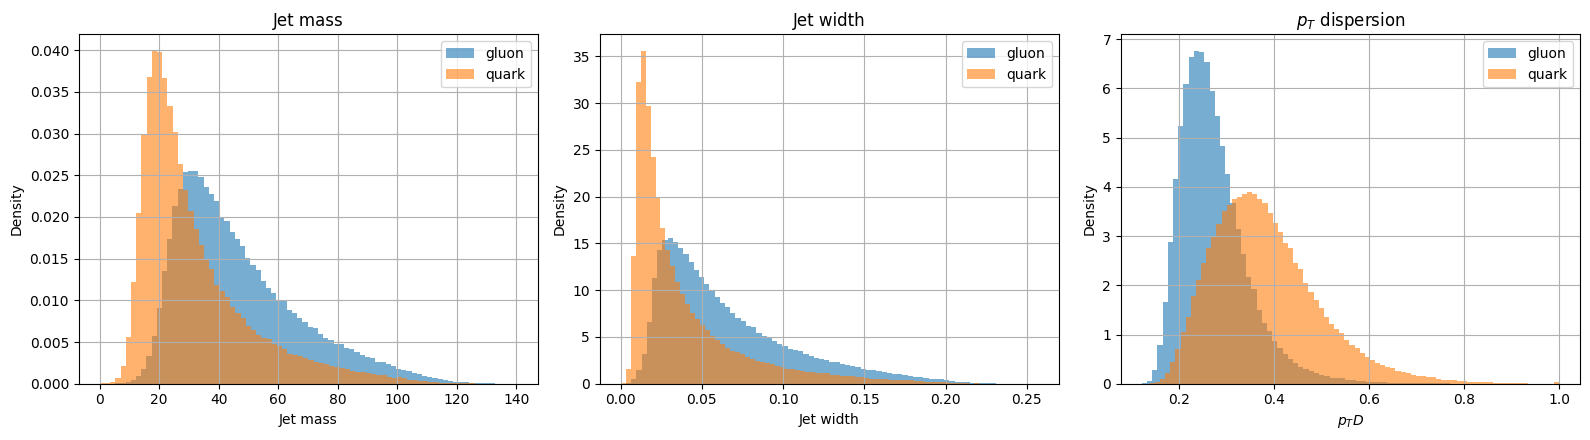

Class-wise means
  mean jet mass  (gluon, quark) = 46.8831, 32.0947
  mean jet width (gluon, quark) = 0.0654, 0.0389
  mean pTD       (gluon, quark) = 0.2728, 0.3826


In [9]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))

ax[0].hist(jet_mass[gmask], bins=80, alpha=0.6, density=True, label="gluon")
ax[0].hist(jet_mass[qmask], bins=80, alpha=0.6, density=True, label="quark")
ax[0].set_xlabel("Jet mass")
ax[0].set_ylabel("Density")
ax[0].set_title("Jet mass")
ax[0].legend()

ax[1].hist(jet_width[gmask], bins=80, alpha=0.6, density=True, label="gluon")
ax[1].hist(jet_width[qmask], bins=80, alpha=0.6, density=True, label="quark")
ax[1].set_xlabel("Jet width")
ax[1].set_ylabel("Density")
ax[1].set_title("Jet width")
ax[1].legend()

ax[2].hist(ptd[gmask], bins=80, alpha=0.6, density=True, label="gluon")
ax[2].hist(ptd[qmask], bins=80, alpha=0.6, density=True, label="quark")
ax[2].set_xlabel("$p_TD$")
ax[2].set_ylabel("Density")
ax[2].set_title("$p_T$ dispersion")
ax[2].legend()

plt.tight_layout()
plt.show()

print("Class-wise means")
print(f"  mean jet mass  (gluon, quark) = {jet_mass[gmask].mean():.4f}, {jet_mass[qmask].mean():.4f}")
print(f"  mean jet width (gluon, quark) = {jet_width[gmask].mean():.4f}, {jet_width[qmask].mean():.4f}")
print(f"  mean pTD       (gluon, quark) = {ptd[gmask].mean():.4f}, {ptd[qmask].mean():.4f}")

## Boost to the jet center-of-mass frame



In [10]:
def load_example_jets(file_paths, n_per_class=1):
    jets_g = []
    jets_q = []
    for path in file_paths:
        data = np.load(path, allow_pickle=False)
        X = data["X"]
        y = data["y"]
        for jet, lab in zip(X, y):
            if lab == 0 and len(jets_g) < n_per_class:
                jets_g.append(jet.copy())
            if lab == 1 and len(jets_q) < n_per_class:
                jets_q.append(jet.copy())
            if len(jets_g) >= n_per_class and len(jets_q) >= n_per_class:
                data.close()
                return jets_g, jets_q
        data.close()
    return jets_g, jets_q

example_gluons, example_quarks = load_example_jets(file_paths, n_per_class=2)
len(example_gluons), len(example_quarks)

(2, 2)

In [11]:
example_jets = example_gluons + example_quarks

for i, jet in enumerate(example_jets, start=1):
    boosted = boost_jet_to_rest_frame(jet)
    psum = boosted[:, 1:].sum(axis=0)
    norm = np.linalg.norm(psum)
    print(f"Jet {i}: |sum p'| = {norm:.6e}, components = {psum}")

Jet 1: |sum p'| = 1.871529e-13, components = [ 0. -0. -0.]
Jet 2: |sum p'| = 2.608520e-12, components = [-0. -0. -0.]
Jet 3: |sum p'| = 3.450164e-12, components = [-0.  0.  0.]
Jet 4: |sum p'| = 2.609986e-12, components = [-0.  0.  0.]


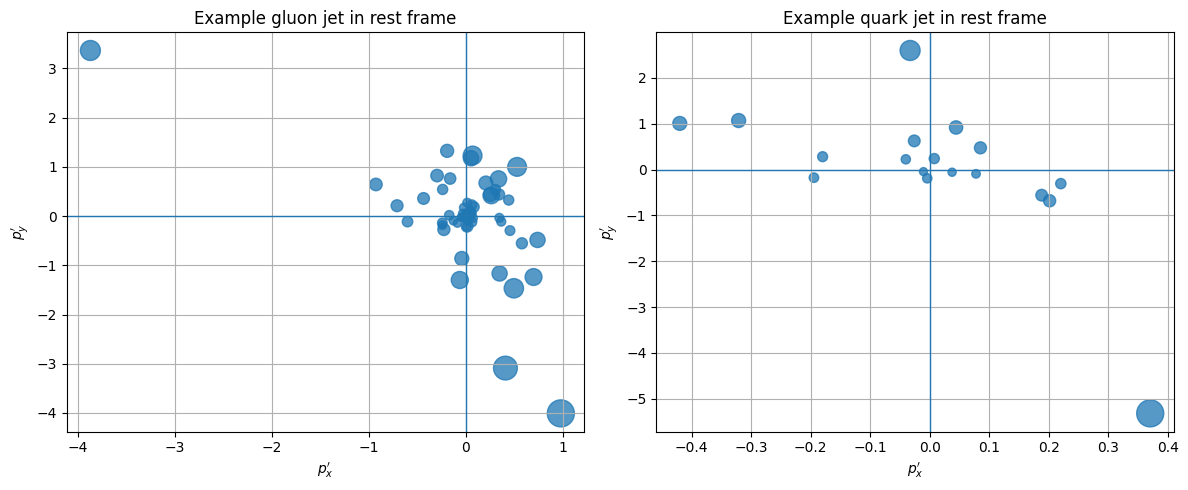

In [12]:
def plot_boosted_jet(ax, jet, title):
    boosted = boost_jet_to_rest_frame(jet)
    Eprime = boosted[:, 0]
    pxprime = boosted[:, 1]
    pyprime = boosted[:, 2]

    sizes = 30 + 350 * Eprime / np.clip(Eprime.max(), 1e-12, None)
    ax.scatter(pxprime, pyprime, s=sizes, alpha=0.75)
    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)
    ax.set_xlabel("$p_x'$")
    ax.set_ylabel("$p_y'$")
    ax.set_title(title)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
plot_boosted_jet(ax[0], example_gluons[0], "Example gluon jet in rest frame")
plot_boosted_jet(ax[1], example_quarks[0], "Example quark jet in rest frame")
plt.tight_layout()
plt.show()

In [13]:
X_lab = np.column_stack([
    multiplicity.astype(np.float64),
    jet_mass.astype(np.float64),
    jet_width.astype(np.float64),
    ptd.astype(np.float64),
    leading_pt.astype(np.float64),
    np.abs(leading_eta.astype(np.float64)),
])

X_rest = np.column_stack([
    multiplicity.astype(np.float64),
    rest_sphericity.astype(np.float64),
    rest_aplanarity.astype(np.float64),
    rest_thrust_like.astype(np.float64),
    rest_max_energy_fraction.astype(np.float64),
    rest_mean_abs_cos_theta.astype(np.float64),
])

feature_names_lab = [
    "multiplicity",
    "jet_mass",
    "jet_width",
    "ptd",
    "leading_pt",
    "abs_leading_eta",
]

feature_names_rest = [
    "multiplicity",
    "rest_sphericity",
    "rest_aplanarity",
    "rest_thrust_like",
    "rest_max_energy_fraction",
    "rest_mean_abs_cos_theta",
]

y_all = labels.astype(np.int64)

idx = np.arange(len(y_all))
rng.shuffle(idx)
split = int(0.8 * len(idx))
tr_idx, te_idx = idx[:split], idx[split:]

def standardize(xtr, xte):
    mu = xtr.mean(axis=0, keepdims=True)
    sig = xtr.std(axis=0, keepdims=True)
    sig = np.where(sig < 1e-12, 1.0, sig)
    return (xtr - mu) / sig, (xte - mu) / sig, mu, sig

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -40, 40)))

def fit_numpy_logistic(Xtr, ytr, lr=0.05, epochs=800, reg=1e-4):
    n, d = Xtr.shape
    w = np.zeros(d, dtype=np.float64)
    b = 0.0
    for _ in range(epochs):
        z = Xtr @ w + b
        p = sigmoid(z)
        err = p - ytr
        gw = (Xtr.T @ err) / n + reg * w
        gb = err.mean()
        w -= lr * gw
        b -= lr * gb
    return w, b

def predict_numpy_logistic(X, w, b):
    return sigmoid(X @ w + b)

def roc_from_scores(y_true, scores):
    order = np.argsort(-scores)
    y = y_true[order]
    P = max((y == 1).sum(), 1)
    N = max((y == 0).sum(), 1)
    tp = np.cumsum(y == 1)
    fp = np.cumsum(y == 0)
    tpr = np.concatenate([[0.0], tp / P, [1.0]])
    fpr = np.concatenate([[0.0], fp / N, [1.0]])
    thr = np.concatenate([[np.inf], scores[order], [-np.inf]])
    auc = np.trapz(tpr, fpr)
    return fpr, tpr, thr, auc

def simple_confusion_matrix(y_true, y_pred):
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    return np.array([[tn, fp], [fn, tp]])

def fit_and_score(X, y, title):
    Xtr, Xte = X[tr_idx], X[te_idx]
    ytr, yte = y[tr_idx], y[te_idx]
    Xtr_s, Xte_s, mu, sig = standardize(Xtr, Xte)

    if SKLEARN_AVAILABLE:
        clf = LogisticRegression(max_iter=2000, random_state=SEED)
        clf.fit(Xtr_s, ytr)
        scores = clf.predict_proba(Xte_s)[:, 1]
    else:
        w, b = fit_numpy_logistic(Xtr_s, ytr.astype(np.float64))
        scores = predict_numpy_logistic(Xte_s, w, b)

    if SKLEARN_AVAILABLE:
        fpr, tpr, thr = roc_curve(yte, scores)
        auc = roc_auc_score(yte, scores)
    else:
        fpr, tpr, thr, auc = roc_from_scores(yte, scores)

    threshold = 0.5
    pred = (scores >= threshold).astype(int)
    cm = confusion_matrix(yte, pred) if SKLEARN_AVAILABLE else simple_confusion_matrix(yte, pred)

    return {
        "title": title,
        "y_test": yte,
        "scores": scores,
        "fpr": fpr,
        "tpr": tpr,
        "threshold": threshold,
        "auc": float(auc),
        "cm": cm,
    }

rest_result = fit_and_score(X_rest, y_all, "Rest-frame classifier")
lab_result = fit_and_score(X_lab, y_all, "Lab-frame baseline")

print(f"Rest-frame AUC : {rest_result['auc']:.5f}")
print(f"Lab-frame AUC  : {lab_result['auc']:.5f}")

Rest-frame AUC : 0.85014
Lab-frame AUC  : 0.85197


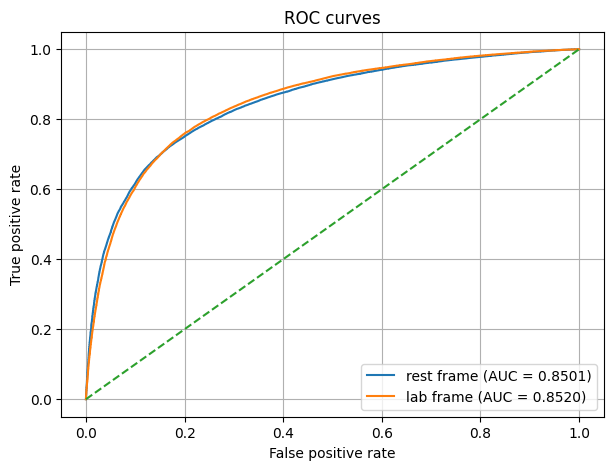

In [14]:
plt.figure(figsize=(7, 5))
plt.plot(rest_result["fpr"], rest_result["tpr"], label=f"rest frame (AUC = {rest_result['auc']:.4f})")
plt.plot(lab_result["fpr"], lab_result["tpr"], label=f"lab frame (AUC = {lab_result['auc']:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curves")
plt.legend()
plt.show()

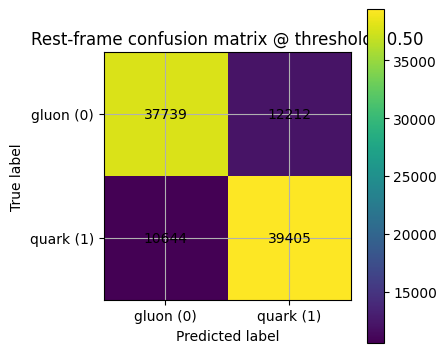

[[37739 12212]
 [10644 39405]]


In [15]:
def show_confusion_matrix(cm, title):
    plt.figure(figsize=(4.5, 4))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    ticks = np.arange(2)
    plt.xticks(ticks, ["gluon (0)", "quark (1)"])
    plt.yticks(ticks, ["gluon (0)", "quark (1)"])
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    for i in range(2):
        for j in range(2):
            plt.text(j, i, int(cm[i, j]), ha="center", va="center")
    plt.tight_layout()
    plt.show()

show_confusion_matrix(rest_result["cm"], f"Rest-frame confusion matrix @ threshold={rest_result['threshold']:.2f}")
print(rest_result["cm"])

In [16]:
def single_feature_auc(x, y):
    if SKLEARN_AVAILABLE:
        a1 = roc_auc_score(y, x)
        a2 = roc_auc_score(y, -x)
        return max(a1, a2)
    else:
        _, _, _, a1 = roc_from_scores(y, x)
        _, _, _, a2 = roc_from_scores(y, -x)
        return max(a1, a2)

single_feature_scores = {}
for i, name in enumerate(feature_names_rest):
    single_feature_scores[name] = single_feature_auc(X_rest[te_idx, i], y_all[te_idx])

best_feature = max(single_feature_scores, key=single_feature_scores.get)
print("Single-feature AUCs (rest-frame set):")
for k, v in single_feature_scores.items():
    print(f"  {k:28s} : {v:.5f}")

print()
print(f"Most discriminating single feature: {best_feature}  (AUC = {single_feature_scores[best_feature]:.5f})")

Single-feature AUCs (rest-frame set):
  multiplicity                 : 0.84098
  rest_sphericity              : 0.68969
  rest_aplanarity              : 0.69104
  rest_thrust_like             : 0.70112
  rest_max_energy_fraction     : 0.77144
  rest_mean_abs_cos_theta      : 0.70112

Most discriminating single feature: multiplicity  (AUC = 0.84098)


In [17]:
if rest_result["auc"] > lab_result["auc"] + 0.005:
    conclusion = "Working in the rest frame helps on this feature set."
elif lab_result["auc"] > rest_result["auc"] + 0.005:
    conclusion = "Working in the rest frame hurts relative to the chosen lab-frame baseline."
else:
    conclusion = "Working in the rest frame makes little difference relative to the chosen lab-frame baseline."

print(conclusion)

Working in the rest frame makes little difference relative to the chosen lab-frame baseline.
